In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid')

In [3]:
aisles         = pd.read_csv('./datasets/aisles.csv')
departments    = pd.read_csv('./datasets/departments.csv')
products       = pd.read_csv('./datasets/products.csv')
orders         = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv')

## EDA

### Quelles sont les pics d'affluences dans la semaine ?

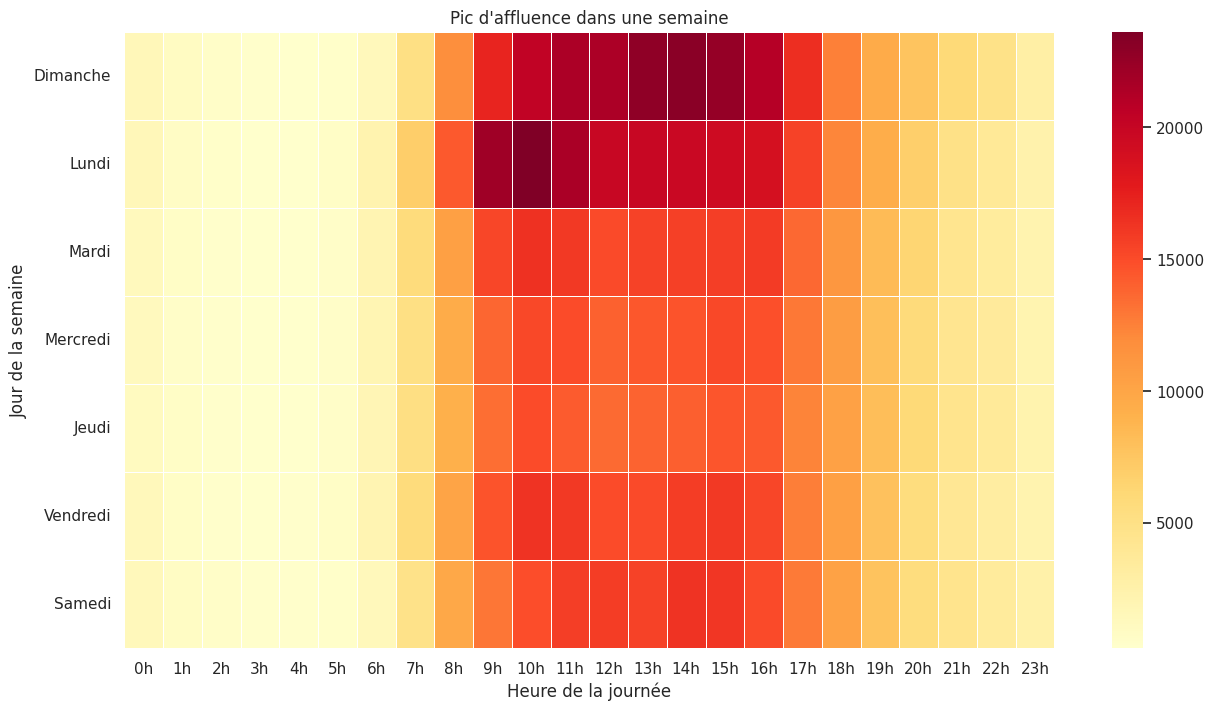

In [5]:

cols = ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


orders = pd.read_csv('./datasets/orders.csv', skiprows=1, names=cols)
group_day_hour=orders.groupby(["order_dow", "order_hour_of_day"])["order_id"].count().reset_index()

orders_tab=group_day_hour.pivot(index='order_dow', columns='order_hour_of_day', values='order_id')


plt.figure(figsize=(15, 8))
sns.heatmap(orders_tab, cmap="YlOrRd", linewidths=.5)

plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
           labels=['Dimanche', 'Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi'], 
           rotation=0)


heures_positions = [i + 0.5 for i in range(24)]
heures_labels = [f"{i}h" for i in range(24)]
plt.xticks(ticks=heures_positions, labels=heures_labels, rotation=0)


plt.title("Pic d'affluence dans une semaine")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()


Observations : 
-  L'affluence est plus forte particulièrement le dimanche entre 13 heures et 15 heures.
-  L'affluence est forte aussi le lundi vers 10 heures.

Améliorations : 
-  Gérer le stock avant pour éviter des ruptures.
-  Mettre plus de personnel à ces moments-la.

In [5]:


#orders_tab.describe()

### Produit le plus souvent mis en premier dans le panier

/tmp/ipykernel_217554/3614065548.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='count', y='product_name', palette='viridis')


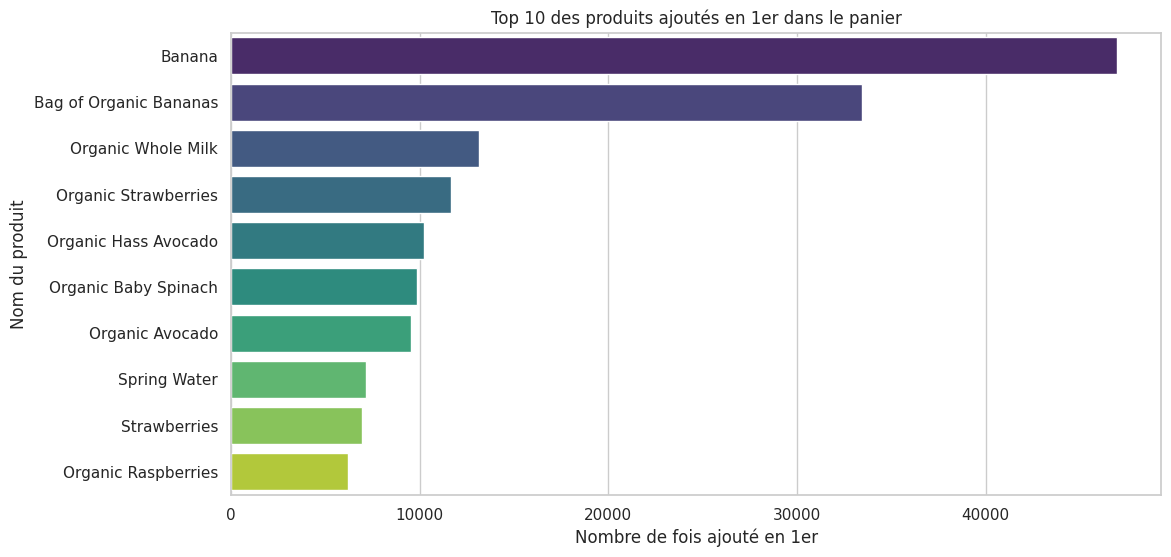

In [6]:
cart_first=order_products[order_products['add_to_cart_order']==1]
count_first_product=cart_first['product_id'].value_counts().reset_index()
count_first_product.columns=['product_id', 'count']



top_merged=pd.merge(count_first_product, products[['product_id', 'product_name']], on='product_id', how='left')
top=top_merged.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top, x='count', y='product_name', palette='viridis')


plt.title("Top 10 des produits ajoutés en 1er dans le panier")
plt.xlabel("Nombre de fois ajouté en 1er")
plt.ylabel("Nom du produit")
plt.show()

Observations :
-  Le produit le plus mis en 1er dans le panier est la banane.
-  Les 10 premiers produits le plus mis en premier dans le panier sont majoritairement des fruits et légumes.
-  Parmi les 10 produits, 7 sont d'origine biologiques.
-  Ce sont une majorité de produits frais qu'on rachète souvent.
-  L'écart entre le 1er et le second est important.

Améliorations : 
-  Améliorer la visibilité de ces produits pour éviter au client de les chercher trop longtemps.
-  S'assurer que ces produits ne sont jamais en rupture de stock.
-  Elargir la part de produits biologiques.

### Quelle est la fréquence à laquelle les clients reviennent faire leurs courses

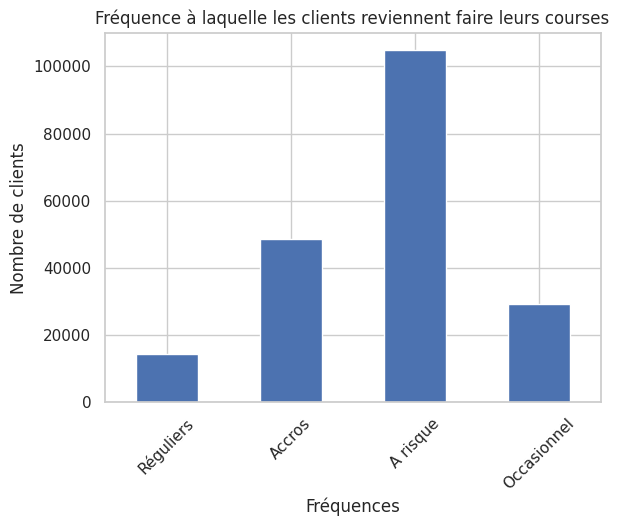

In [7]:
df_reorders = orders.dropna(subset=['days_since_prior_order'])
freq = df_reorders['days_since_prior_order'].mean()
freq_by_custmer = df_reorders.groupby('user_id')['days_since_prior_order'].mean()

bornes = [0, 5, 10, 25, float('inf')]
etiq = ["Réguliers", "Accros", "A risque", "Occasionnel"]
segments = pd.cut(freq_by_custmer, bins=bornes, labels=etiq)
count = segments.value_counts()
count.reindex(etiq).plot(kind='bar')
plt.title("Fréquence à laquelle les clients reviennent faire leurs courses")
plt.xlabel("Fréquences")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.show()

Observation : 
- Plus de 100.000 clients sont "A risque", ce qui veut dire qu'ils ne reviennent pas souvent ou sinon rarement. Il s'écoule beaucoup de jours avant qu'ils reviennent
- Plus de 40.000 clients sont "Accros", très peu de jours s'écroule entre leurs jours de courses
- Plus de 20.000 sont "Occasionnels", un nombre raisonnable de jour s'épuisent entre leurs courses
- Plus de 10.000 clients sont "Réguliers",  peu de jours passent entre leurs courses.

### Quels rayons finissent le plus souvent en fin de panier ?

/tmp/ipykernel_217554/3891551319.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


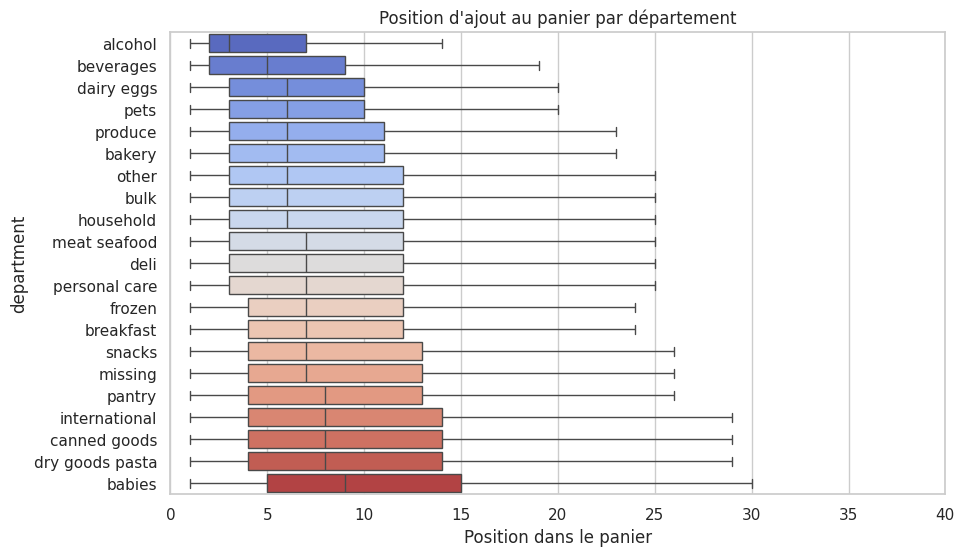

In [8]:
product_merged=pd.merge(order_products, products[['product_id', 'department_id']], on='product_id', how='left')
name_merged=pd.merge(product_merged, departments, on='department_id', how='left')

group_department=name_merged.groupby("department")["add_to_cart_order"].mean().reset_index()
group_department = group_department.sort_values(by="add_to_cart_order")


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=name_merged, 
    x='add_to_cart_order', 
    y='department', 
    order=group_department['department'],
    palette='coolwarm',
    showfliers=False
)

plt.title("Position d'ajout au panier par département")
plt.xlabel("Position dans le panier")

plt.xlim(0, 40) 

plt.show()

Compréhension du graphique (Boxplot) :
-  La partie avant la boîte de couleur représente 25% des clients les plus rapides à mettre l'article dans le panier.
-  La boîte représente 50 % des clients.
-  Après la boîte c'est les 25% restants les plus lents.
-  L'axe x donne l'ordre et les boîtes la proportion de clients qui le fait à ce moment-la.
-  Le trait au milieu de la boîte représente la médiane le client 50, indique la position typique du client du milieu.
-  Les traits noirs extérieurs représentent les extrêmes.

Avantage :
-  Montre l'étendue des comportements, permet de voir si les clients agissent de la même manière.
-  Une moyenne aurait été faussé par des comportements rares, la médiane observe le comportement d'un client typique.
-  Plusieurs d'informations d'un coup.
-  Plus nuancé qu'un barplot.

Observations : 
-  Les achats le plus souvent fait en 1er sont dans les rayons alcools, boissons et crémerie. Presque tout le monde commence ses courses par ces produits.
-  Les articles d'épicerie et pour bébés sont ajoutés beaucoup plus tard, ce sont des achats complémentaires.
-  Plus on descend dans le graphique plus les boîtes sont larges ce qui montre une grande variabilité dans les habitudes contrairement à l'alcool.

Améliorations :
-  Mettre en évidence les produits le plus souvent mis en 1er afin de faire gagner du temps au client.
-  Proposer les produits d'épiceries juste avant le paiement pour qu'il achète avec impulsion.
-  Améliorer le parcours client.

### Quel est le produit le plus populaire ?

<Axes: >

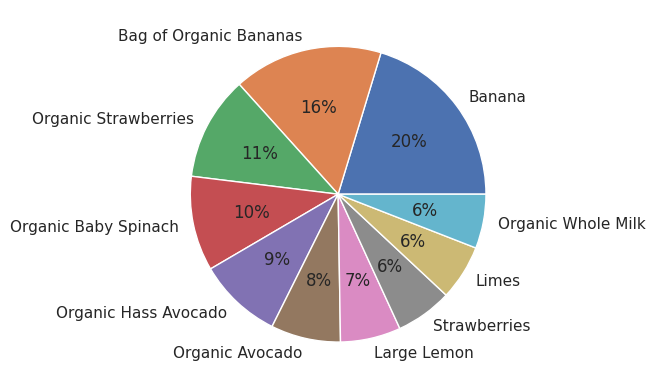

In [9]:
order_complete = order_products.merge(products, on='product_id')
result =order_complete['product_name'].value_counts().head(10)
result.plot(kind='pie', autopct='%1.0f%%')

Observations : 
- La banane est le produit le plus populaire, avec le sac de banane bio.
- On peut voir un lien avec le produit qui est placé en premier dans le panier, la banane est populaire et est placée en premiere dans le panier.

### Quelle est la part des produits biologiques achetée ?

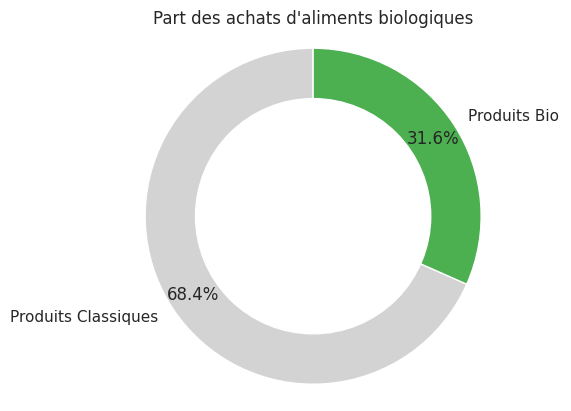

In [10]:
df_bio=pd.merge(order_products, products[['product_id', 'product_name']], on='product_id', how='left')

df_bio['type_product']=df_bio['product_name'].str.contains('Organic', case=False, na=False)
df_bio['type_product'] = df_bio['type_product'].map({True: 'Produits Bio', False: 'Produits Classiques'})
repartition=df_bio['type_product'].value_counts()


plt.pie(
    repartition,
        labels=repartition.index, 
        autopct='%1.1f%%',
        startangle=90,     
        colors=['#d3d3d3', '#4CAF50'], 
        pctdistance=0.85
)

centre_cercle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_cercle)

plt.title("Part des achats d'aliments biologiques")
plt.axis('equal')
plt.show()

Observations :
-  Près d'un article sur 3 acheté par les clients est d'origine bio.

Améliorations :
-  Elargir la gamme de produits bio.
-  Mettre encore plus avant ces produits.

### Quelles allées et quels rayons ont le plus de produits ?

/tmp/ipykernel_217554/789397093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_dept.values, y=top_dept.index, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_217554/789397093.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aisles.values, y=top_aisles.index, ax=axes[1], palette='Oranges_r')


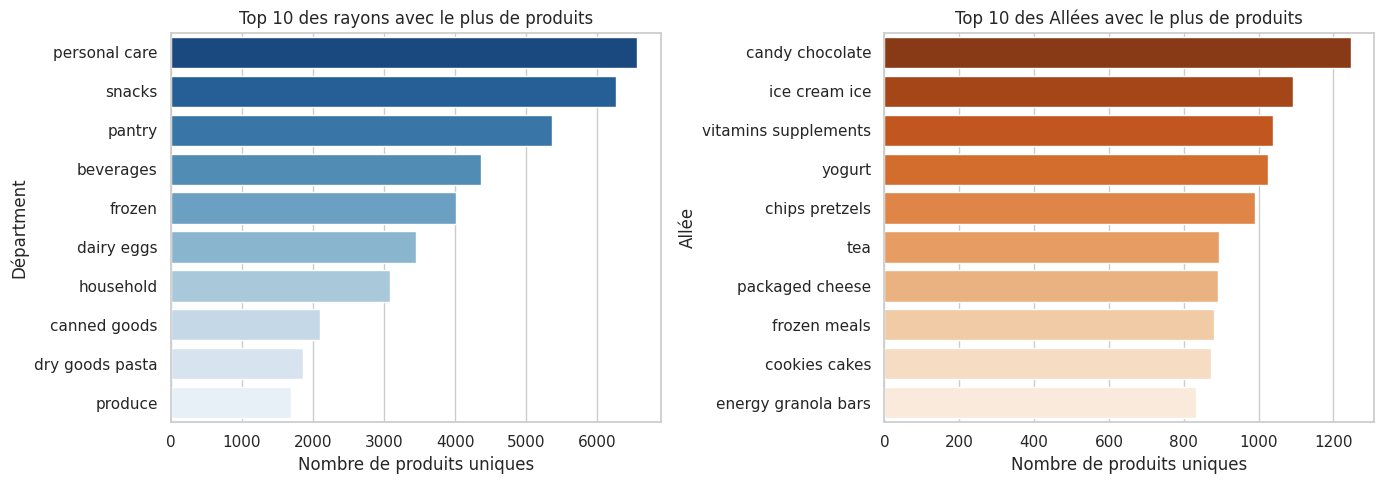

In [11]:



df_dept=pd.merge(products, departments, on='department_id', how='left')

df_dept=pd.merge(df_dept,aisles, on='aisle_id', how='left')

#df_dept.head()
df_clean=df_dept[df_dept['aisle']!='missing']
top_dept=df_clean['department'].value_counts().head(10)

top_aisles=df_clean['aisle'].value_counts().head(10)


fig, axes =plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top_dept.values, y=top_dept.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 des rayons avec le plus de produits')
axes[0].set_xlabel('Nombre de produits uniques')
axes[0].set_ylabel('Départment')


sns.barplot(x=top_aisles.values, y=top_aisles.index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 des Allées avec le plus de produits')
axes[1].set_xlabel('Nombre de produits uniques')
axes[1].set_ylabel('Allée')


plt.tight_layout()
plt.show()



Observations :
-  Les rayons hygiène et snacks sont ceux qui ont le plus de diversités avec plus de 6000 références.
-  Les allées les plus remplies sont celles des bonbons/ chocolats, des glaces, le client cherche des saveurs précises.
-  Le rayon qui génère généralement le plus de vente (Produce) est néanmoins celui qui possède le moins de référence.

Améliorations :
-  Analyser si les 6000 produits se vendent réellement, éviter des références inutiles.
-  Le commerce peut négocier les prix la où il y a moins de références car il achète en plus grande quantité.

### Certains rayons connaissent-ils des pics de commandes très concentrés sur une heure de la journée par rapport aux autres ?

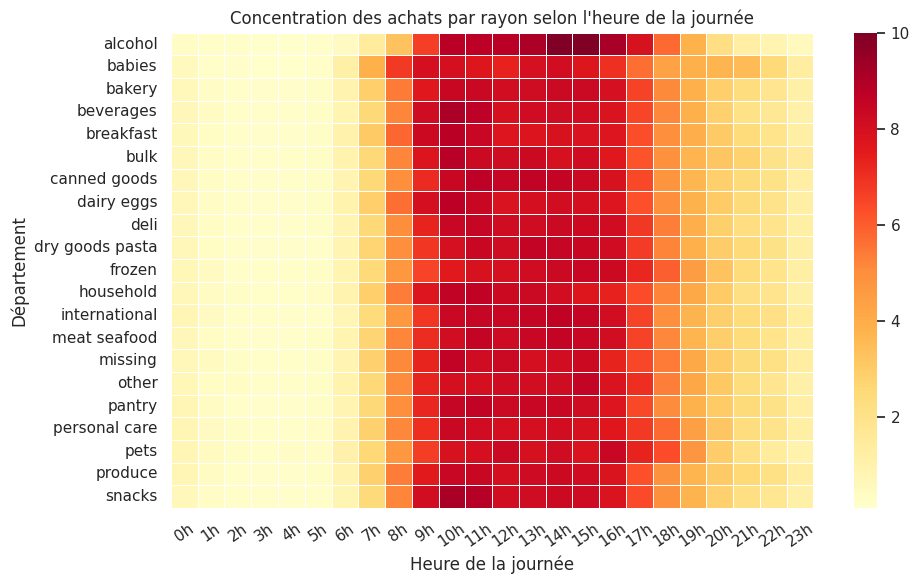

In [8]:
df_ventes=pd.merge(order_products, orders[['order_id', 'order_dow', 'order_hour_of_day']], on='order_id', how='left')
df_ventes=pd.merge(df_ventes, products[['product_id', 'department_id']], on='product_id', how='left')
df_ventes=pd.merge(df_ventes, departments, on='department_id', how='left')


tab=pd.crosstab(df_ventes['department'], df_ventes['order_hour_of_day'], normalize='index') *100


plt.figure(figsize=(10, 6))
sns.heatmap(tab, cmap="YlOrRd", linewidths=.5)

heures_positions = [i + 0.5 for i in range(24)]
heures_labels = [f"{i}h" for i in range(24)]
plt.xticks(ticks=heures_positions, labels=heures_labels, rotation=35)

plt.title("Concentration des achats par rayon selon l'heure de la journée")
plt.xlabel("Heure de la journée")
plt.ylabel("Département")

plt.tight_layout()
plt.show()


Observations :
-  Le rayon Babies commence un peu plus tôt que les autres.
-  Le rayon Alcohol connaît un pic vers 14h et continue jusqu'à 18 h.

Utilité du graphique :
-  Vérifier si certains rayons connaissait des pics d'affluence or ce n'est pas réellement le cas.
-  N'apporte aucune valeur au commerce.
-  L'heure de la journée n'est pas un facteur déterminant.

## Modèles

## Feature Preparation

In [13]:
#associe la commande au client avec tout les détails
df_historique=pd.merge(order_products, orders, on='order_id', how='inner')

#volume total des ventes, taux moyen de réachat de chaque article, groupe par produit
product_group=df_historique.groupby('product_id').agg(
    product_total_achat=('order_id', 'count'),
    product_reorder=('reordered', 'mean')
).reset_index()

#groupe par utilisateur pour son profil
user_group=df_historique.groupby('user_id').agg(
    user_total_com=('order_number', 'max'),
    user_total_product=('product_id', 'count')
).reset_index()

user_group['user_cart_mean']=user_group['user_total_product']/user_group['user_total_com']

#Lien entre le client et certains produits 

lien=df_historique.groupby(['user_id', 'product_id']).agg(
    rep_achat=('order_id', 'count')
).reset_index()


#rassemblement final
df_final=pd.merge(lien, user_group, on='user_id', how='left')

df_final=pd.merge(df_final, product_group, on='product_id', how='left')


# df_final.head(100)

In [14]:
last_order=df_historique.groupby('user_id')['order_number'].max().reset_index()

product_last_order=pd.merge(last_order, df_historique, on=['user_id', 'order_number'], how='inner')

product_last_order['cible']=1
product_reor=product_last_order[['user_id', 'product_id', 'cible']]

df_fin=pd.merge(df_final, product_reor, on=['user_id', 'product_id'], how='left')

df_fin['cible']=df_fin['cible'].fillna(0)

df_fin.head()


,user_id,product_id,rep_achat,user_total_com,user_total_product,user_cart_mean,product_total_achat,product_reorder,cible
0,1.0,196.0,7,10.0,44,4.4,14994,0.778111,1.0
1,1.0,10258.0,6,10.0,44,4.4,842,0.719715,1.0
2,1.0,10326.0,1,10.0,44,4.4,2351,0.655891,0.0
3,1.0,12427.0,7,10.0,44,4.4,2633,0.750095,1.0
4,1.0,13032.0,2,10.0,44,4.4,1593,0.645101,1.0


### Régréssion Logistique

In [15]:
X=df_fin.drop(columns=['user_id', 'product_id', 'cible'])
y = df_fin['cible']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred=logreg.predict(X_test)


Comparative Evaluation - Logistic Regression


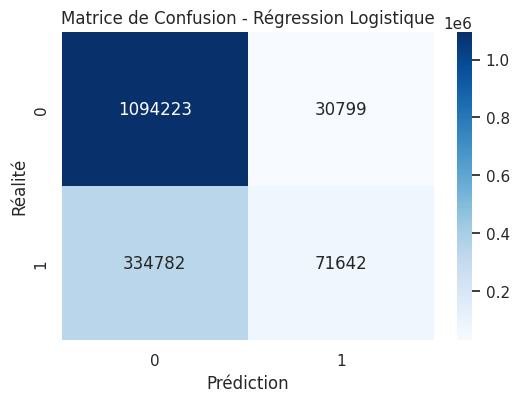

In [16]:
matrice = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Régression Logistique')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

In [17]:
print(classification_report(y_test, y_pred, target_names=['Non racheté', 'Racheté']))

              precision    recall  f1-score   support

 Non racheté       0.77      0.97      0.86   1125022
     Racheté       0.70      0.18      0.28    406424

    accuracy                           0.76   1531446
   macro avg       0.73      0.57      0.57   1531446
weighted avg       0.75      0.76      0.70   1531446



### Random Forest

À partir du profil d'un utilisateur et des caractéristiques d'un produit, le modèle prédit si ce produit sera racheté lors de la prochaine commande.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Comparative Evaluation - Random Forest Regressor

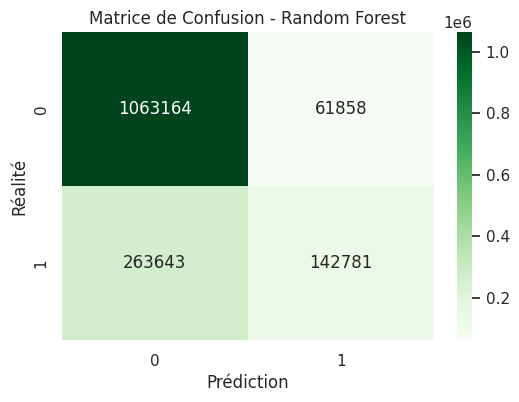

              precision    recall  f1-score   support

 Non racheté       0.80      0.95      0.87   1125022
     Racheté       0.70      0.35      0.47    406424

    accuracy                           0.79   1531446
   macro avg       0.75      0.65      0.67   1531446
weighted avg       0.77      0.79      0.76   1531446



In [ ]:
matrice_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(matrice_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=['Non racheté', 'Racheté']))

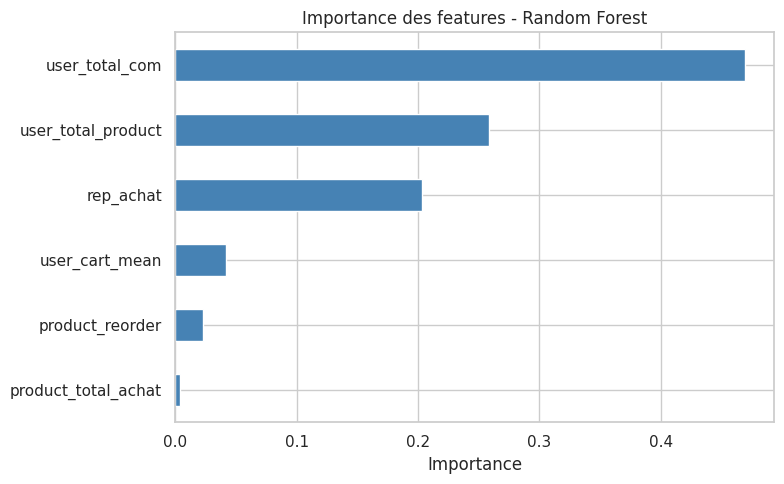

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Importance des features - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Comparaison des modèles

                       Accuracy  Précision  Rappel  F1-Score
Modèle                                                      
Régression Logistique    0.7613     0.6993  0.1763    0.2816
Random Forest            0.7875     0.6977  0.3513    0.4673


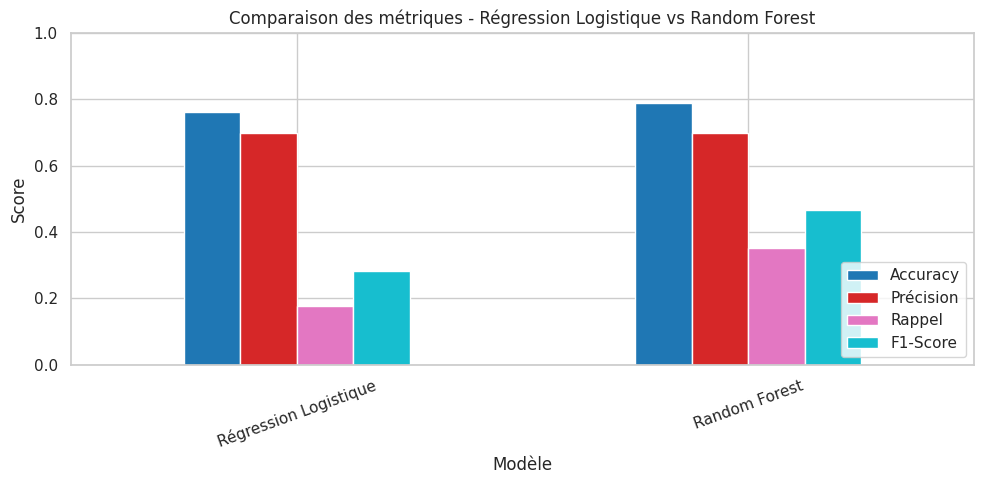

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

metrics = {
    'Modèle': ['Régression Logistique', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred),  accuracy_score(y_test, y_pred_rf)],
    'Précision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_rf)],
    'Rappel':    [recall_score(y_test, y_pred),    recall_score(y_test, y_pred_rf)],
    'F1-Score':  [f1_score(y_test, y_pred),        f1_score(y_test, y_pred_rf)],
}

df_metrics = pd.DataFrame(metrics).set_index('Modèle')
print(df_metrics.round(4))

df_metrics.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=20, colormap='tab10')
plt.title("Comparaison des métriques - Régression Logistique vs Random Forest")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Observations :
- Le Random Forest capture mieux les relations non-linéaires entre les features (répétition d'achat, profil utilisateur, popularité produit).
- Le graphique d'importance des features montre quelles variables pèsent le plus dans la décision : typiquement `rep_achat` et `product_reorder`
- Le Random Forest obtient généralement un meilleur F1-Score sur la classe "Racheté", ce qui est l'objectif principal de la prédiction.

TODO :
- test hyperparamètres
- autres features (ex:`days_since_prior_order`)
- LightGBM/GBoosting